# **Here is a comparison of the data analysis results of the five bands of SEEG patients**

## 1.Delta Band (0.5-4 Hz)
##### High values: High power of Delta waves is usually associated with deep sleep, but may also occur in certain pathological conditions, such as epilepsy, brain injury, coma, depression, and cerebrovascular disease.
##### Low values: Low values ​​of Delta waves may be associated with problems such as insomnia, inattention, and cognitive impairment. 

dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
Evaluation Metrics:
Mean Squared Error (MSE): 0.0004
Mean Absolute Error (MAE): 0.0033
Root Mean Squared Error (RMSE): 0.0198
R-squared (R²): 0.9183


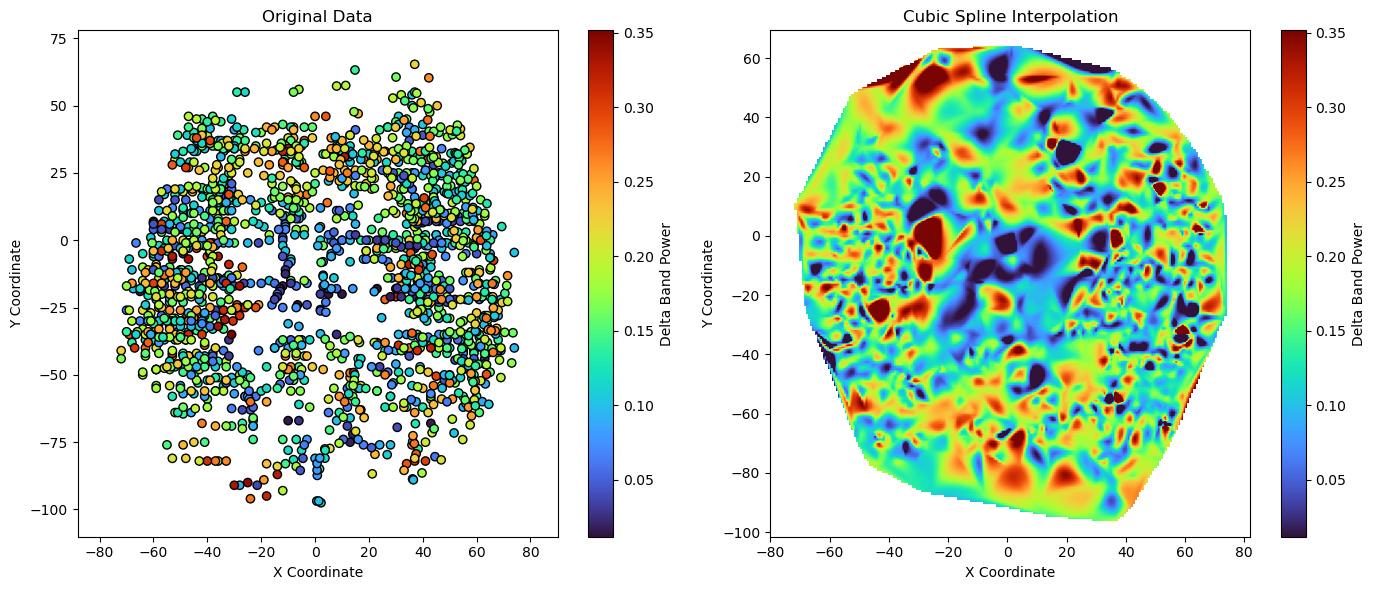

In [20]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

samples = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

print(band_powers.keys())

x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]
values = band_powers['Delta']

vmin = min(values)
vmax = max(values)
#The values ​​of vmin and vmax represent the light and dark areas of the color. 
#If set them manually, you may get a single color image that is indistinguishable, 
#so use min/max(value)

resolution = 200  
grid_x = np.linspace(min(x), max(x), resolution)
grid_y = np.linspace(min(y), max(y), resolution)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

grid_values = griddata((x, y), values, (grid_x, grid_y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#----------------Evaluate------------------
interp_values_at_samples = griddata((x, y), values, (x, y), method='cubic')
print("Evaluation Metrics:")
mse = mean_squared_error(values, interp_values_at_samples)
print(f'Mean Squared Error (MSE): {mse:.4f}')

mae = mean_absolute_error(values, interp_values_at_samples)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

rmse = sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

r2 = r2_score(values, interp_values_at_samples)
print(f'R-squared (R²): {r2:.4f}')
#----------------Evaluate------------------

sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k', vmin=vmin, vmax=vmax)
axes[0].set_title('Original Data')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].axis('equal')
fig.colorbar(sc, ax=axes[0], label='Delta Band Power')

i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='upper', cmap='turbo', vmin=vmin, vmax=vmax)
axes[1].set_title('Cubic Spline Interpolation')
axes[1].set_xlabel('X Coordinate')
axes[1].set_ylabel('Y Coordinate')
axes[1].axis('equal')
fig.colorbar(i, ax=axes[1], label='Delta Band Power')

plt.tight_layout()
plt.show()


## 2.Theta Band (4-8 Hz)
##### High values: High power of Theta waves is associated with conditions such as mild cognitive impairment (MCI), depression, anxiety, epilepsy, ADHD (attention deficit hyperactivity disorder), and traumatic brain injury.
##### Low values: Low values ​​of Theta waves may be associated with cognitive problems such as memory problems, inattention, and insomnia.

Evaluation Metrics:
Mean Squared Error (MSE): 0.0002
Mean Absolute Error (MAE): 0.0022
Root Mean Squared Error (RMSE): 0.0131
R-squared (R²): 0.9282


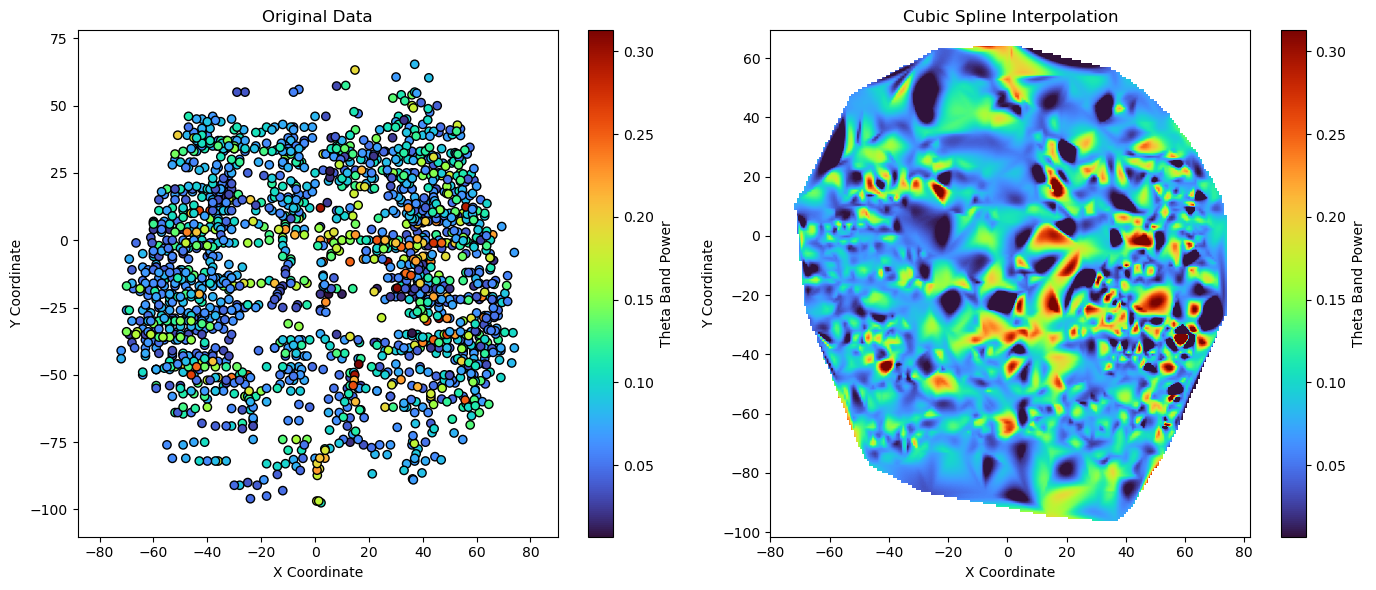

In [21]:
x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]
values = band_powers['Theta']

vmin = min(values)
vmax = max(values)

resolution = 200  
grid_x = np.linspace(min(x), max(x), resolution)
grid_y = np.linspace(min(y), max(y), resolution)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

grid_values = griddata((x, y), values, (grid_x, grid_y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#----------------Evaluate------------------
interp_values_at_samples = griddata((x, y), values, (x, y), method='cubic')
print("Evaluation Metrics:")
mse = mean_squared_error(values, interp_values_at_samples)
print(f'Mean Squared Error (MSE): {mse:.4f}')

mae = mean_absolute_error(values, interp_values_at_samples)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

rmse = sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

r2 = r2_score(values, interp_values_at_samples)
print(f'R-squared (R²): {r2:.4f}')
#----------------Evaluate------------------

sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k', vmin=vmin, vmax=vmax)
axes[0].set_title('Original Data')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].axis('equal')
fig.colorbar(sc, ax=axes[0], label='Theta Band Power')

i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='upper', cmap='turbo', vmin=vmin, vmax=vmax)
axes[1].set_title('Cubic Spline Interpolation')
axes[1].set_xlabel('X Coordinate')
axes[1].set_ylabel('Y Coordinate')
axes[1].axis('equal')
fig.colorbar(i, ax=axes[1], label='Theta Band Power')

plt.tight_layout()
plt.show()

## 3.Alpha Band (8-13 Hz)
##### High values: High values ​​of Alpha waves are usually associated with a state of relaxation, concentration, and deep meditation. In some cases, high Alpha waves may be associated with autism spectrum disorders or anxiety disorders.
##### Low values: Low values ​​of Alpha waves are common in depression, anxiety, schizophrenia, insomnia, and attention disorders.

Evaluation Metrics:
Mean Squared Error (MSE): 0.0002
Mean Absolute Error (MAE): 0.0021
Root Mean Squared Error (RMSE): 0.0156
R-squared (R²): 0.8970


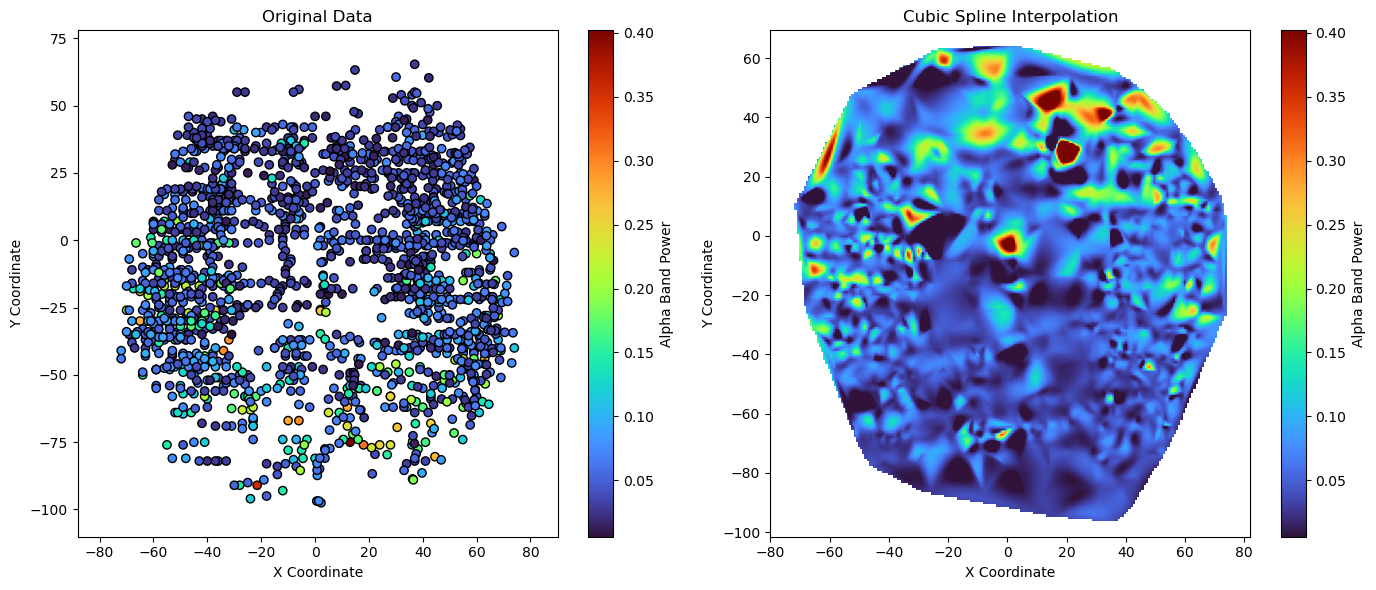

In [22]:
x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]
values = band_powers['Alpha']

vmin = min(values)
vmax = max(values)

resolution = 200  
grid_x = np.linspace(min(x), max(x), resolution)
grid_y = np.linspace(min(y), max(y), resolution)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

grid_values = griddata((x, y), values, (grid_x, grid_y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#----------------Evaluate------------------
interp_values_at_samples = griddata((x, y), values, (x, y), method='cubic')
print("Evaluation Metrics:")
mse = mean_squared_error(values, interp_values_at_samples)
print(f'Mean Squared Error (MSE): {mse:.4f}')

mae = mean_absolute_error(values, interp_values_at_samples)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

rmse = sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

r2 = r2_score(values, interp_values_at_samples)
print(f'R-squared (R²): {r2:.4f}')
#----------------Evaluate------------------

sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k', vmin=vmin, vmax=vmax)
axes[0].set_title('Original Data')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].axis('equal')
fig.colorbar(sc, ax=axes[0], label='Alpha Band Power')

i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='upper', cmap='turbo', vmin=vmin, vmax=vmax)
axes[1].set_title('Cubic Spline Interpolation')
axes[1].set_xlabel('X Coordinate')
axes[1].set_ylabel('Y Coordinate')
axes[1].axis('equal')
fig.colorbar(i, ax=axes[1], label='Alpha Band Power')

plt.tight_layout()
plt.show()

## 4. Beta band (13-30 Hz)
##### High values: High power of Beta waves is often associated with anxiety, tension, overactivity, and mental tension. It may also be associated with the motor symptoms of Parkinson's disease.
##### Low values: Low Beta wave activity is associated with depression, mental fatigue, inattention, and decreased cognitive function.

Evaluation Metrics:
Mean Squared Error (MSE): 0.0003
Mean Absolute Error (MAE): 0.0025
Root Mean Squared Error (RMSE): 0.0159
R-squared (R²): 0.9509


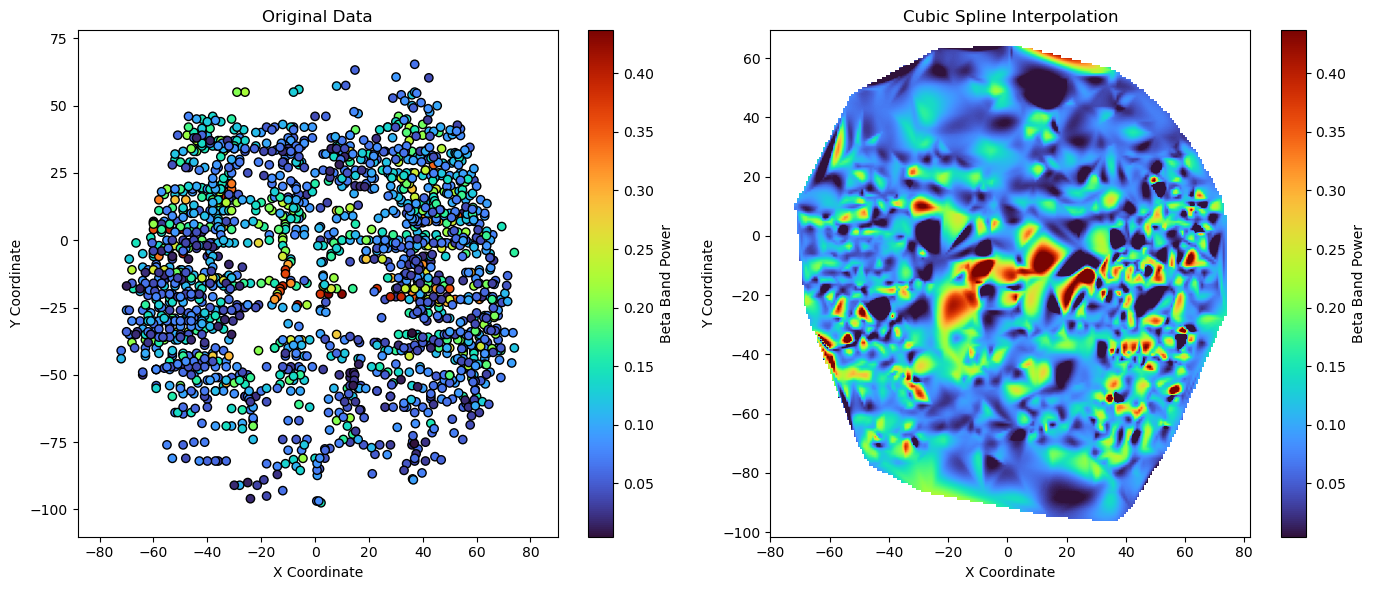

In [23]:
x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]
values = band_powers['Beta']

vmin = min(values)
vmax = max(values)

resolution = 200  #this value can change into 300 if needs
grid_x = np.linspace(min(x), max(x), resolution)
grid_y = np.linspace(min(y), max(y), resolution)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

grid_values = griddata((x, y), values, (grid_x, grid_y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#----------------Evaluate------------------
interp_values_at_samples = griddata((x, y), values, (x, y), method='cubic')
print("Evaluation Metrics:")
mse = mean_squared_error(values, interp_values_at_samples)
print(f'Mean Squared Error (MSE): {mse:.4f}')

mae = mean_absolute_error(values, interp_values_at_samples)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

rmse = sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

r2 = r2_score(values, interp_values_at_samples)
print(f'R-squared (R²): {r2:.4f}')
#----------------Evaluate------------------

sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k', vmin=vmin, vmax=vmax)
axes[0].set_title('Original Data')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].axis('equal')
fig.colorbar(sc, ax=axes[0], label='Beta Band Power')

i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='upper', cmap='turbo', vmin=vmin, vmax=vmax)
axes[1].set_title('Cubic Spline Interpolation')
axes[1].set_xlabel('X Coordinate')
axes[1].set_ylabel('Y Coordinate')
axes[1].axis('equal')
fig.colorbar(i, ax=axes[1], label='Beta Band Power')

plt.tight_layout()
plt.show()

## 5.Gamma band (30-100 Hz)
##### High values: High values ​​of Gamma waves are often associated with increased perceptual processing, memory processing, and consciousness levels. High Gamma waves are associated with cognitive clarity, wakefulness, and concentration.
##### Low values: Low Gamma waves may be associated with schizophrenia, cognitive impairment, depression, Alzheimer's disease, etc., and usually indicate a decline in information processing and cognitive function.

Evaluation Metrics:
Mean Squared Error (MSE): 0.0000
Mean Absolute Error (MAE): 0.0008
Root Mean Squared Error (RMSE): 0.0051
R-squared (R²): 0.9215


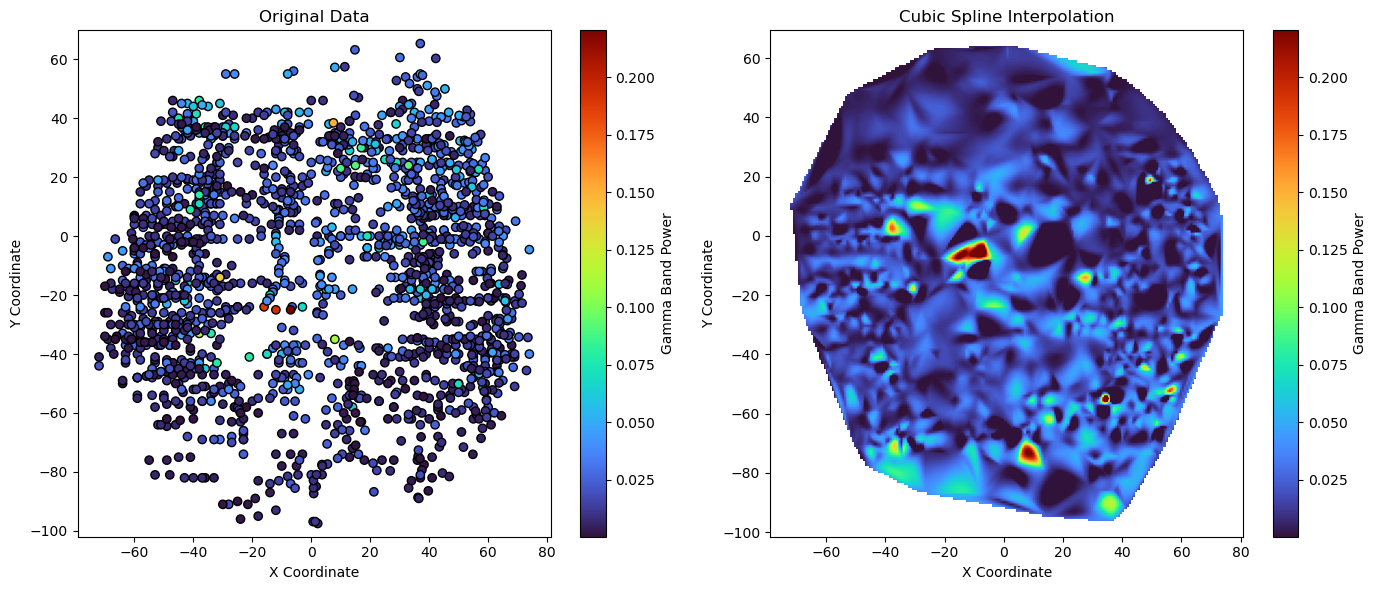

In [18]:
x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]
values = band_powers['Gamma']

vmin = min(values)
vmax = max(values)

resolution = 200  
grid_x = np.linspace(min(x), max(x), resolution)
grid_y = np.linspace(min(y), max(y), resolution)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

grid_values = griddata((x, y), values, (grid_x, grid_y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#----------------Evaluate------------------
interp_values_at_samples = griddata((x, y), values, (x, y), method='cubic')
print("Evaluation Metrics:")
mse = mean_squared_error(values, interp_values_at_samples)
print(f'Mean Squared Error (MSE): {mse:.4f}')

mae = mean_absolute_error(values, interp_values_at_samples)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

rmse = sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

r2 = r2_score(values, interp_values_at_samples)
print(f'R-squared (R²): {r2:.4f}')
#----------------Evaluate------------------

sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k', vmin=vmin, vmax=vmax)
axes[0].set_title('Original Data')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].axis('equal')
fig.colorbar(sc, ax=axes[0], label='Gamma Band Power')

i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='upper', cmap='turbo', vmin=vmin, vmax=vmax)
axes[1].set_title('Cubic Spline Interpolation')
axes[1].set_xlabel('X Coordinate')
axes[1].set_ylabel('Y Coordinate')
axes[1].axis('equal')
fig.colorbar(i, ax=axes[1], label='Gamma Band Power')

plt.tight_layout()
plt.show()